In [107]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [108]:
df = pd.read_csv("USA Housing Dataset.csv")

In [109]:
df.columns = df.columns.str.strip()
print(df.columns)

Index(['date', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot',
       'floors', 'waterfront', 'view', 'condition', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'street', 'city',
       'statezip', 'country'],
      dtype='object')


In [110]:
df.drop(["date","country"],axis=1,inplace=True)

In [111]:
df = df.drop(columns=["street"])

In [112]:
df.columns = df.columns.str.strip()
print(df.columns)

Index(['price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
       'waterfront', 'view', 'condition', 'sqft_above', 'sqft_basement',
       'yr_built', 'yr_renovated', 'city', 'statezip'],
      dtype='object')


In [113]:
df.shape

(4140, 15)

In [114]:
df = df[df["price"] > 0]

print(df.shape)

(4091, 15)


Numerical Columns:
Index(['price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
       'waterfront', 'view', 'condition', 'sqft_above', 'sqft_basement',
       'yr_built', 'yr_renovated'],
      dtype='object')


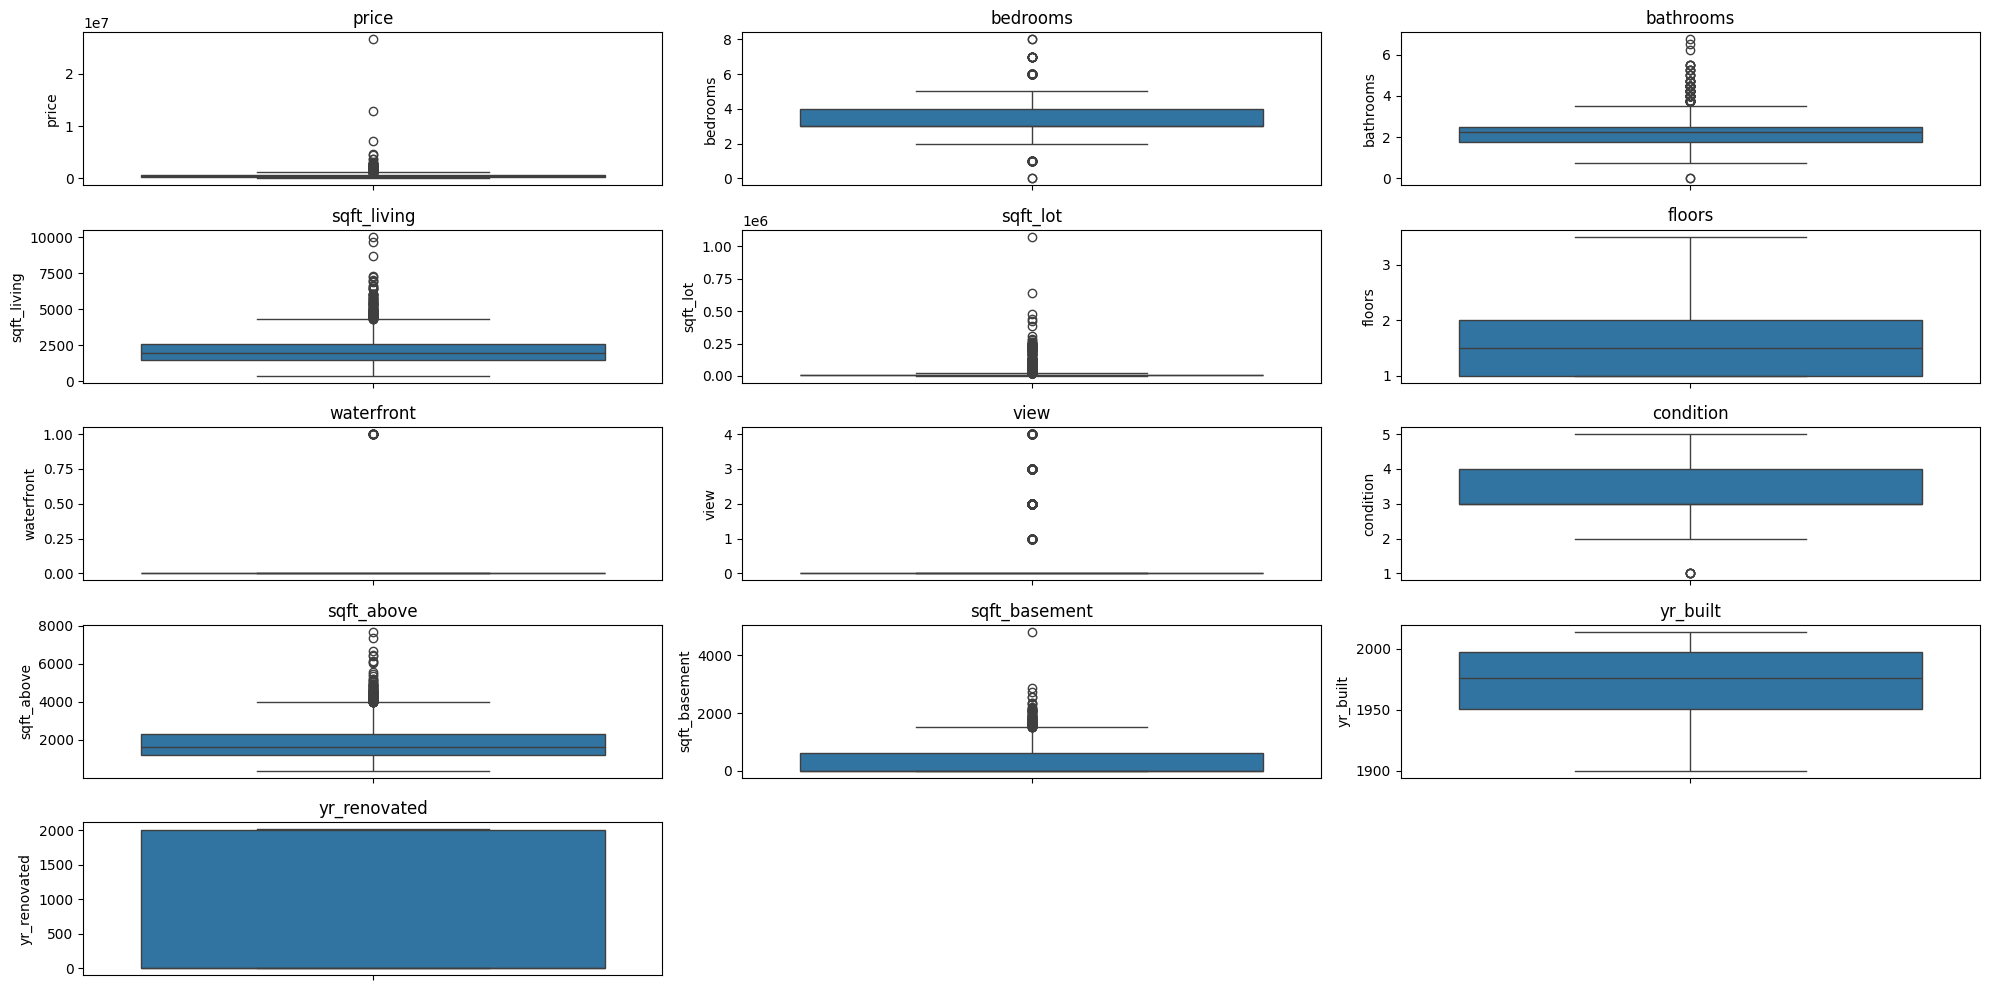

In [115]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

print("Numerical Columns:")
print(num_cols)


plt.figure(figsize=(20, 10))

for i, col in enumerate(num_cols, 1):
    plt.subplot((len(num_cols) + 2) // 3, 3, i)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

In [116]:
outlier_summary = []

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

    outlier_summary.append({
        "Column": col,
        "Outlier_Count": len(outliers),
        "Outlier_Percentage": round(len(outliers) / len(df) * 100, 2)
    })

outlier_df = pd.DataFrame(outlier_summary)
outlier_df = outlier_df.sort_values("Outlier_Count", ascending=False)

print(outlier_df)

           Column  Outlier_Count  Outlier_Percentage
4        sqft_lot            478               11.68
7            view            406                9.92
0           price            216                5.28
3     sqft_living            118                2.88
2       bathrooms            117                2.86
1        bedrooms            105                2.57
9      sqft_above            104                2.54
10  sqft_basement             79                1.93
6      waterfront             28                0.68
8       condition              5                0.12
5          floors              0                0.00
11       yr_built              0                0.00
12   yr_renovated              0                0.00


In [117]:
outlier_cols = [
    'price',
    'bedrooms',
    'bathrooms',
    'sqft_living',
    'sqft_lot',
    'sqft_above',
    'sqft_basement'
]

print("Original Shape:", df.shape)

for col in outlier_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df = df[
        (df[col] >= lower) &
        (df[col] <= upper)
    ]

print("Cleaned Shape:", df.shape)

Original Shape: (4091, 15)
Cleaned Shape: (3191, 15)


Numerical Columns:
['price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated']


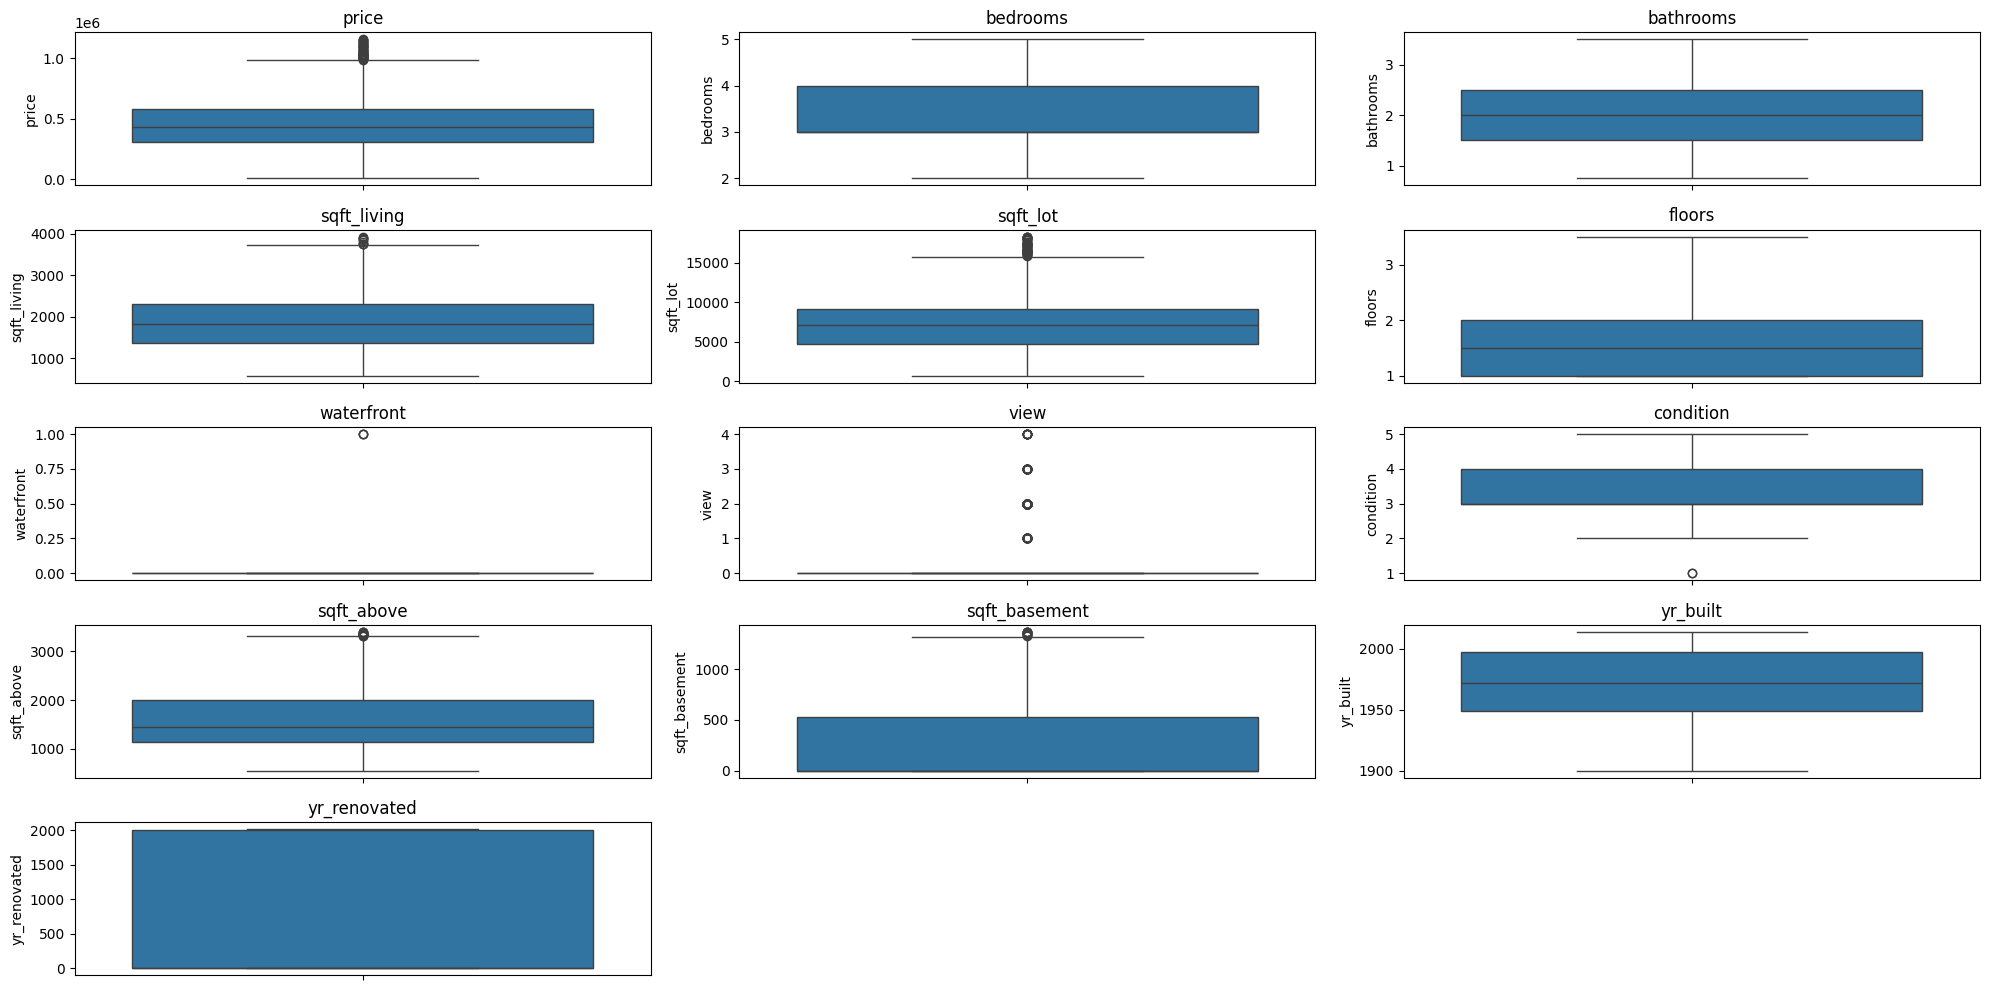

In [118]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

print("Numerical Columns:")
print(list(num_cols))

plt.figure(figsize=(20, 10))

for i, col in enumerate(num_cols, 1):
    plt.subplot((len(num_cols) + 2) // 3, 3, i)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

In [119]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3191 entries, 0 to 4139
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   price          3191 non-null   float64
 1   bedrooms       3191 non-null   float64
 2   bathrooms      3191 non-null   float64
 3   sqft_living    3191 non-null   int64  
 4   sqft_lot       3191 non-null   int64  
 5   floors         3191 non-null   float64
 6   waterfront     3191 non-null   int64  
 7   view           3191 non-null   int64  
 8   condition      3191 non-null   int64  
 9   sqft_above     3191 non-null   int64  
 10  sqft_basement  3191 non-null   int64  
 11  yr_built       3191 non-null   int64  
 12  yr_renovated   3191 non-null   int64  
 13  city           3191 non-null   object 
 14  statezip       3191 non-null   object 
dtypes: float64(4), int64(9), object(2)
memory usage: 398.9+ KB


In [120]:
from sklearn.preprocessing import LabelEncoder

object_cols = df.select_dtypes(include='object').columns

le_dict = {}

for col in object_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    le_dict[col] = le

print("Encoding Completed!")
print(df.dtypes)

Encoding Completed!
price            float64
bedrooms         float64
bathrooms        float64
sqft_living        int64
sqft_lot           int64
floors           float64
waterfront         int64
view               int64
condition          int64
sqft_above         int64
sqft_basement      int64
yr_built           int64
yr_renovated       int64
city               int64
statezip           int64
dtype: object


In [121]:
df["price"] = np.log1p(df["price"])

In [122]:
print(df["price"].describe())

count    3191.000000
mean       12.951001
std         0.445744
min         8.962007
25%        12.640857
50%        12.971543
75%        13.270785
max        13.961688
Name: price, dtype: float64


In [123]:
df["house_age"] = 2025 - df["yr_built"]

df["renovated"] = np.where(
    df["yr_renovated"] > 0,
    1,
    0
)

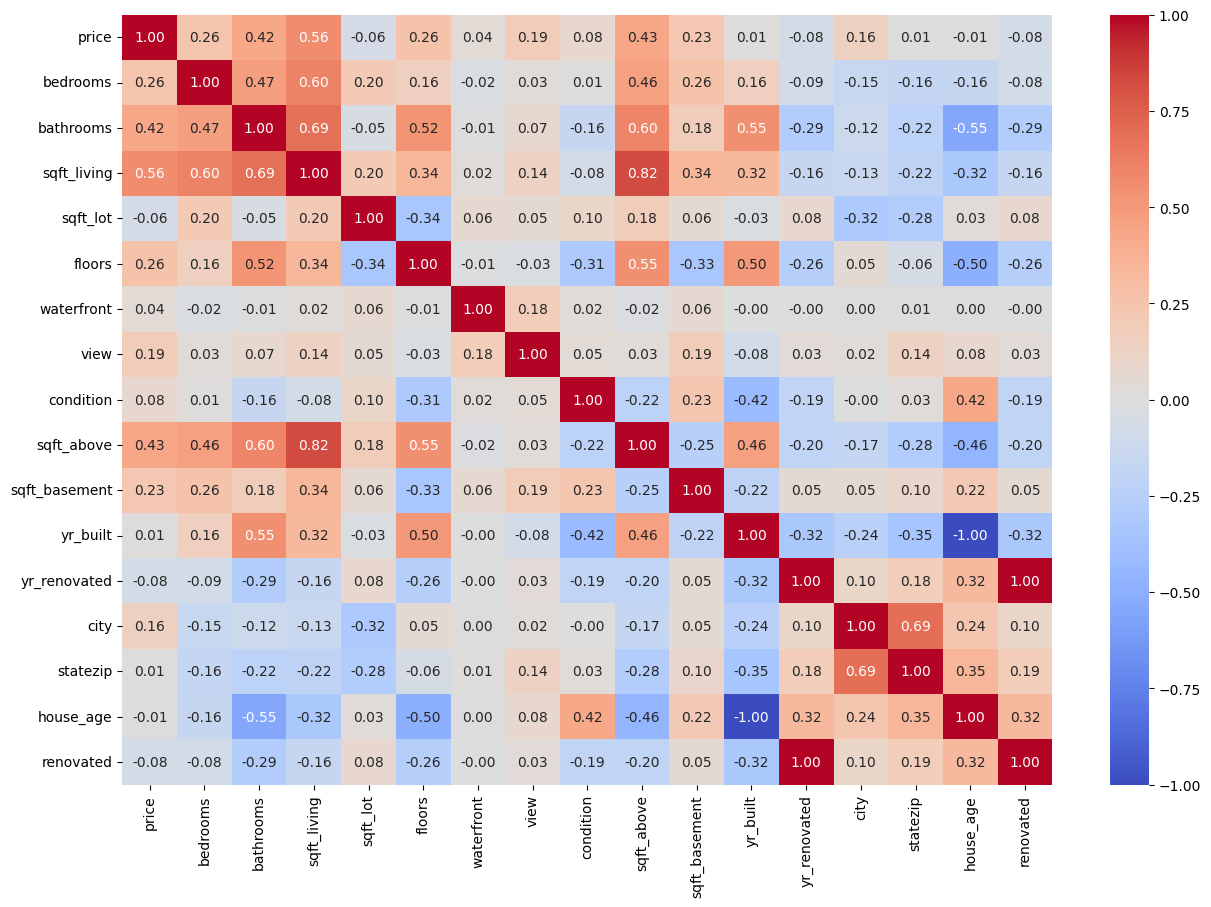

In [124]:
plt.figure(figsize=(15,10))

sns.heatmap(
    df.corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm'
)

plt.show()

In [125]:
df = df.drop(columns=['yr_built'])

In [126]:
df = df.drop(columns=['yr_renovated'])

In [127]:
df.columns = df.columns.str.strip()
print(df.columns)

Index(['price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
       'waterfront', 'view', 'condition', 'sqft_above', 'sqft_basement',
       'city', 'statezip', 'house_age', 'renovated'],
      dtype='object')


In [128]:
X = df.drop('price', axis=1)

y = df['price']

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(2552, 14)
(639, 14)


In [129]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print(X_train_scaled.shape)
print(X_test_scaled.shape)

(2552, 14)
(639, 14)


In [130]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train_scaled, y_train)

pred = lr.predict(X_test_scaled)

In [131]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [132]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

import numpy as np

In [133]:
print("Linear Regression")

print("MAE:", mean_absolute_error(y_test, pred))

print("RMSE:", np.sqrt(mean_squared_error(y_test, pred)))

print("R²:", r2_score(y_test, pred))

Linear Regression
MAE: 0.25973267220757174
RMSE: 0.3299514813000766
R²: 0.40472825559808356


In [134]:
print("Random Forest")

print("MAE:", mean_absolute_error(y_test, rf_pred))

print("RMSE:", np.sqrt(mean_squared_error(y_test, rf_pred)))

print("R²:", r2_score(y_test, rf_pred))

Random Forest
MAE: 0.17290569110429205
RMSE: 0.24224361757697302
R²: 0.6791368885892173


In [135]:
import joblib

joblib.dump(rf, "house_price_model.pkl")

['house_price_model.pkl']

In [136]:
loaded_model = joblib.load("house_price_model.pkl")

In [137]:
print(X.columns)

Index(['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
       'waterfront', 'view', 'condition', 'sqft_above', 'sqft_basement',
       'city', 'statezip', 'house_age', 'renovated'],
      dtype='object')


In [138]:
new_house = pd.DataFrame({
    'bedrooms': [3],
    'bathrooms': [2],
    'sqft_living': [1800],
    'sqft_lot': [5000],
    'floors': [2],
    'waterfront': [0],
    'view': [2],
    'condition': [3],
    'sqft_above': [1500],
    'sqft_basement': [300],
    'city': ['Seattle'],
    'statezip': ['WA 98119'],
    'house_age': [20],
    'renovated': [0]
})

In [139]:
categorical_cols = ['city', 'statezip']

for col in categorical_cols:
    new_house[col] = le_dict[col].transform(new_house[col].astype(str))

In [140]:
new_house = new_house[X.columns]

In [143]:
import numpy as np

predicted_log_price = loaded_model.predict(new_house)

predicted_price = np.exp(predicted_log_price)

print(f"Predicted House Price: ${predicted_price[0]:,.2f}")

Predicted House Price: $531,879.97
